# Clasificador Sanrio 26 Clases — EfficientNet-B0 v3

**Diplomado Superior RNA y Deep Learning — UAEM**  
**Módulo 4: Deep Learning | Proyecto Final**  
**Autora:** Diana Blanco — MorritaConP1to

### ¿Qué cambió de v2 a v3?

| Aspecto | v2 (ResNet18) | v3 (EfficientNet-B0) |
|---------|--------------|---------------------|
| Arquitectura | ResNet18 | EfficientNet-B0 |
| Clases | 29 | 26 (se quitaron 3 conflictivas) |
| Dataset | original desbalanceado | curado, cap 220 img/clase |
| Accuracy | 65.2% | ~75-82% esperado |
| Por qué EfficientNet | — | Mejor en fine-grained (clases similares) |

### Clases eliminadas y por qué

| Clase | Motivo |
|-------|--------|
| `charmmykitty` | Casi idéntica a hello_kitty (variante con collar) |
| `my_sweet_piano` | Casi idéntica a my_melody (variante con piano) |
| `little_twin_stars` | Dos personajes en una carpeta — el modelo no sabe a quién clasificar |

### Pipeline

```
dataset/train_v2/ + test_v2/  (generados por curar_dataset.py)
    → EfficientNet-B0 pretrained (ImageNet)
    → Fase 1: solo cabeza (10 épocas)
    → Fase 2: fine-tuning top layers (30 épocas + early stopping)
    → modelos/tl_sanrio_v3_final.pth
    → export a ONNX INT8 → models/tl_sanrio_v3_int8.onnx
```

> **Antes de correr:** asegúrate de haber ejecutado `curar_dataset.py`  
> para generar `dataset/train_v2/` y `dataset/test_v2/`

In [1]:
# ============================================================
# Celda 1 — Setup: imports, rutas, hiperparámetros
#
# RUTA_BASE se auto-detecta igual que en v2:
#   - Si corres desde notebooks/ → sube un nivel
#   - Si corres desde Final/     → usa el cwd
# ============================================================

import os, sys, time, json, warnings, gc, copy
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

warnings.filterwarnings('ignore')

AUTORA = 'Diana Blanco - MorritaConP1to'
VERSION = 'v3-EfficientNet'
INICIO = time.time()
SEMILLA = 42
torch.manual_seed(SEMILLA)
np.random.seed(SEMILLA)

# ── Detectar RUTA_BASE ──────────────────────────────────────
cwd = os.getcwd()
if os.path.basename(cwd) == 'notebooks':
    RUTA_BASE = os.path.dirname(cwd)
elif os.path.isdir(os.path.join(cwd, 'dataset')):
    RUTA_BASE = cwd
else:
    RUTA_BASE = cwd

RUTA_DATASET = os.path.join(RUTA_BASE, 'dataset')
RUTA_MODELOS = os.path.join(RUTA_BASE, 'modelos')
RUTA_MODELS  = os.path.join(RUTA_BASE, 'models')
os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_MODELS,  exist_ok=True)

# ── Hiperparámetros ─────────────────────────────────────────
# ¿Por qué estos valores?
#   BATCH_SIZE 32: EfficientNet tolera batches más grandes que ResNet18
#   LR_FASE1 0.005: EfficientNet tiene BN interno, LR alta puede desestabilizar
#   LR_FASE2 0.0003: fine-tuning conservador para no destruir features ImageNet
#   EPOCHS_FASE2 30: más épocas porque el dataset es más limpio y pequeño
#   PATIENCE 7: más tolerancia que v2 (5) porque EfficientNet converge más lento
CONFIG = {
    'BATCH_SIZE':    32,
    'EPOCHS_FASE1':  10,
    'EPOCHS_FASE2':  30,
    'LR_FASE1':      0.005,
    'LR_FASE2':      0.0003,
    'DROPOUT':       0.4,       # Ligeramente más alto que v2 (0.3)
    'PATIENCE':      7,
    'MOMENTUM':      0.9,
    'WEIGHT_DECAY':  1e-4,
    'GRAD_CLIP':     1.0,
    'T_MAX':         30,
    'LABEL_SMOOTHING': 0.1,     # NUEVO en v3: suaviza la confianza, reduce overfit
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'CONFIG: {json.dumps(CONFIG, indent=2)}')

# Verificar que curar_dataset.py ya se ejecutó
train_path = os.path.join(RUTA_DATASET, 'train_v2')
test_path  = os.path.join(RUTA_DATASET, 'test_v2')
if not os.path.isdir(train_path):
    raise FileNotFoundError(
        f'No se encuentra {train_path}.\n'
        f'Ejecuta curar_dataset.py primero.'
    )
print(f'\nDataset train_v2/: {len(os.listdir(train_path))} clases detectadas')

Device: cuda
CONFIG: {
  "BATCH_SIZE": 32,
  "EPOCHS_FASE1": 10,
  "EPOCHS_FASE2": 30,
  "LR_FASE1": 0.005,
  "LR_FASE2": 0.0003,
  "DROPOUT": 0.4,
  "PATIENCE": 7,
  "MOMENTUM": 0.9,
  "WEIGHT_DECAY": 0.0001,
  "GRAD_CLIP": 1.0,
  "T_MAX": 30,
  "LABEL_SMOOTHING": 0.1
}

Dataset train_v2/: 26 clases detectadas


## Data Augmentation v3

Misma estrategia que v2 pero con dos adiciones clave:

| Transformación | Por qué |
|---------------|--------|
| RandomResizedCrop | Personaje no centrado |
| RandomHorizontalFlip | Foto desde el otro lado |
| RandomRotation ±20° | Cámara inclinada |
| ColorJitter 20% | Distinta iluminación |
| RandomAffine translate 10% | Pequeño desplazamiento |
| **RandomGrayscale 10%** | **NUEVO: imágenes B&N o de baja saturación** |
| **RandomErasing 10%** | **NUEVO: simula oclusión parcial del personaje** |

In [2]:
# ============================================================
# Celda 2 — Dataset, augmentación, loaders
# ============================================================

# EfficientNet-B0 fue entrenado con 224x224 igual que ResNet
# pero el paper recomienda 240x240 → crop a 224 para más contexto
transform_train = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomGrayscale(p=0.10),   # Nuevo v3
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.10,      # Nuevo v3: oclusión simulada
                             scale=(0.02, 0.15)),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=train_path, transform=transform_train)
test_dataset  = ImageFolder(root=test_path,  transform=transform_test)

clases    = train_dataset.classes
NUM_CLASES = len(clases)
print(f'Clases detectadas: {NUM_CLASES}')
print(f'  {clases}\n')

# Guardar JSON de clases para el deploy
clases_json_path = os.path.join(RUTA_MODELOS, 'clases_sanrio_v3.json')
with open(clases_json_path, 'w', encoding='utf-8') as f:
    json.dump(clases, f, ensure_ascii=False, indent=2)
print(f'Clases guardadas en {clases_json_path}')

# ── Pesos por clase (igual que v2) ──────────────────────────
conteos = []
for c in clases:
    carpeta = os.path.join(train_path, c)
    n = len([f for f in os.listdir(carpeta)
             if os.path.isfile(os.path.join(carpeta, f))])
    conteos.append(n)

total_imgs = sum(conteos)
pesos_clase = torch.tensor(
    [total_imgs / max(c, 1) for c in conteos],
    dtype=torch.float
).to(device)

print('Distribución de clases:')
for c, n, p in sorted(zip(clases, conteos, pesos_clase.cpu().tolist()),
                       key=lambda x: x[1], reverse=True):
    barra = '#' * max(1, int(n / 8))
    print(f'  {c:25s}: {n:4d} img  {barra}')
print(f'\nTotal train: {total_imgs} imágenes')

# WeightedRandomSampler para batches balanceados
pesos_muestras = [
    pesos_clase[train_dataset.targets[i]].item()
    for i in range(len(train_dataset))
]
sampler = WeightedRandomSampler(
    weights=pesos_muestras,
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(
    train_dataset, batch_size=CONFIG['BATCH_SIZE'],
    sampler=sampler, num_workers=0,
    pin_memory=(device.type == 'cuda')
)
test_loader = DataLoader(
    test_dataset, batch_size=CONFIG['BATCH_SIZE'],
    shuffle=False, num_workers=0,
    pin_memory=(device.type == 'cuda')
)
print(f'Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}')

Clases detectadas: 26
  ['aggretsuko', 'badtz_maru', 'chococat', 'cinnamon', 'cogimyun', 'dear_daniel', 'gaopowerroo', 'gudetama', 'hanamaruobake', 'hangyodon', 'hello_kitty', 'keroppi', 'kirimichan', 'kuririn', 'kuromi', 'marroncream', 'marumofubiyori', 'my_melody', 'pekkle', 'pochacco', 'pompompurin', 'sugarbunnies', 'tuxedo_sam', 'usahana', 'wish_me_mell', 'yoshikitty']

Clases guardadas en d:\Diplomado-RNA\Modulo-4\Proyectos\Final\modelos\clases_sanrio_v3.json
Distribución de clases:
  cinnamon                 :  220 img  ###########################
  kuromi                   :  220 img  ###########################
  gudetama                 :  170 img  #####################
  hangyodon                :  167 img  ####################
  pompompurin              :  167 img  ####################
  tuxedo_sam               :  166 img  ####################
  dear_daniel              :  165 img  ####################
  my_melody                :  165 img  ####################
  badtz_maru

## Modelo: EfficientNet-B0

### ¿Por qué EfficientNet-B0 en lugar de ResNet18?

EfficientNet escala la red en tres dimensiones simultáneamente (profundidad,
ancho, resolución) mediante un coeficiente compuesto. Esto lo hace especialmente
bueno para clasificación **fine-grained** — donde las diferencias entre clases
son sutiles (ej. Kuromi vs Chococat, ambos negros con orejas).

| Métrica | ResNet18 | EfficientNet-B0 |
|---------|----------|-----------------|
| Parámetros | 11.7M | 5.3M |
| ImageNet Top-1 | 69.8% | 77.1% |
| Tamaño ONNX approx | ~43 MB | ~20 MB |
| Fine-grained datasets | Bueno | Mejor |

### Estrategia de fine-tuning

EfficientNet tiene bloques MBConv (convoluciones invertidas con squeeze-excitation).
Descongelamos los últimos 3 bloques en la Fase 2 — equivalente a descongelar
layer3+layer4 en ResNet18.

In [3]:
# ============================================================
# Celda 3 — Definir modelo EfficientNet-B0
# ============================================================

# Cargar EfficientNet-B0 con pesos de ImageNet
weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
model = models.efficientnet_b0(weights=weights)

# ── Congelar todo para Fase 1 ───────────────────────────────
for param in model.parameters():
    param.requires_grad = False

# ── Reemplazar cabeza classifier ────────────────────────────
# EfficientNet-B0 tiene features de 1280 en su ultima capa
# Agregamos Dropout + Linear nueva para nuestras N clases
in_features = model.classifier[1].in_features  # 1280
model.classifier = nn.Sequential(
    nn.Dropout(p=CONFIG['DROPOUT'], inplace=True),
    nn.Linear(in_features, NUM_CLASES)
)

model = model.to(device)

# ── Resumen de parámetros ───────────────────────────────────
total_p     = sum(p.numel() for p in model.parameters())
entrena_p   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros totales:     {total_p:,}')
print(f'Parámetros entrenables: {entrena_p:,} '
      f'({100*entrena_p/total_p:.1f}%)')
print(f'Clases de salida:       {NUM_CLASES}')

# ── Loss con Label Smoothing ────────────────────────────────
# label_smoothing=0.1 significa que en lugar de one-hot dura [0,0,1,0],
# el target es [0.005, 0.005, 0.9, 0.005, ...]
# Esto previene que el modelo sea demasiado confiado en clases similares
criterion = nn.CrossEntropyLoss(
    weight=pesos_clase,
    label_smoothing=CONFIG['LABEL_SMOOTHING']
)
print(f'\nLoss: CrossEntropy con pesos de clase + label_smoothing={CONFIG["LABEL_SMOOTHING"]}')

Parámetros totales:     4,040,854
Parámetros entrenables: 33,306 (0.8%)
Clases de salida:       26

Loss: CrossEntropy con pesos de clase + label_smoothing=0.1


In [4]:
# ============================================================
# Celda 4 — Función de entrenamiento (igual que v2, reutilizable)
# ============================================================

def entrenar(modelo, train_loader, test_loader, criterion,
             optimizer, scheduler, num_epochs, device, nombre):
    """
    Loop de entrenamiento con:
      - Early stopping basado en val_loss
      - Gradient clipping para estabilidad
      - Restauración del mejor modelo al terminar
    """
    historial = {'train_loss': [], 'test_loss': [], 'test_acc': []}
    mejor_loss  = float('inf')
    mejor_state = None
    patience    = 0
    t0          = time.time()

    for epoch in range(num_epochs):
        # ── Train ──
        modelo.train()
        train_loss = 0.0
        for imagenes, etiquetas in train_loader:
            imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
            optimizer.zero_grad()
            outputs = modelo(imagenes)
            loss = criterion(outputs, etiquetas)
            loss.backward()
            # Gradient clipping: evita explosión de gradientes en fine-tuning
            nn.utils.clip_grad_norm_(modelo.parameters(), CONFIG['GRAD_CLIP'])
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # ── Validación ──
        modelo.eval()
        test_loss = 0.0
        correctos = 0
        total     = 0
        with torch.no_grad():
            for imagenes, etiquetas in test_loader:
                imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
                outputs   = modelo(imagenes)
                loss      = criterion(outputs, etiquetas)
                test_loss += loss.item()
                _, predichos = torch.max(outputs, 1)
                total     += etiquetas.size(0)
                correctos += (predichos == etiquetas).sum().item()
        test_loss /= len(test_loader)
        accuracy   = 100.0 * correctos / total

        historial['train_loss'].append(train_loss)
        historial['test_loss'].append(test_loss)
        historial['test_acc'].append(accuracy)

        lr_actual = optimizer.param_groups[0]['lr']
        elapsed   = time.time() - t0
        print(f'{nombre} [{epoch+1:2d}/{num_epochs}]  '
              f'T Loss: {train_loss:.4f}  V Loss: {test_loss:.4f}  '
              f'Acc: {accuracy:.2f}%  LR: {lr_actual:.6f}  '
              f'{elapsed:.0f}s')

        if scheduler is not None:
            scheduler.step()

        # Early stopping
        if test_loss < mejor_loss:
            mejor_loss  = test_loss
            mejor_state = copy.deepcopy(modelo.state_dict())
            patience    = 0
        else:
            patience += 1
            if patience >= CONFIG['PATIENCE']:
                print(f'  ⏹ Early stopping en época {epoch+1}')
                break

    modelo.load_state_dict(mejor_state)
    print(f'  ✅ Mejor modelo restaurado (val_loss={mejor_loss:.4f})')
    return historial

## Fase 1 — Solo la cabeza

Todos los bloques de EfficientNet congelados.  
Solo entrenamos el nuevo `classifier` que reemplazamos.  
Objetivo: que la cabeza aprenda a interpretar los features de ImageNet  
antes de hacer fine-tuning.

In [5]:
# ============================================================
# Celda 5 — FASE 1: Solo cabeza
# ============================================================

print('=' * 65)
print('FASE 1: ENTRENANDO CABEZA (EfficientNet congelado)')
print('=' * 65)

optimizer_fase1 = optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['LR_FASE1'],
    momentum=CONFIG['MOMENTUM'],
    weight_decay=CONFIG['WEIGHT_DECAY'],
    nesterov=True
)

scheduler_fase1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_fase1, T_max=CONFIG['EPOCHS_FASE1']
)

entrena_f1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables Fase 1: {entrena_f1:,}\n')

historial1 = entrenar(
    model, train_loader, test_loader, criterion,
    optimizer_fase1, scheduler_fase1,
    CONFIG['EPOCHS_FASE1'], device, 'Fase1'
)

FASE 1: ENTRENANDO CABEZA (EfficientNet congelado)
Parámetros entrenables Fase 1: 33,306

Fase1 [ 1/10]  T Loss: 3.0947  V Loss: 2.9604  Acc: 30.43%  LR: 0.005000  80s
Fase1 [ 2/10]  T Loss: 2.7547  V Loss: 2.6971  Acc: 43.78%  LR: 0.004878  143s
Fase1 [ 3/10]  T Loss: 2.5247  V Loss: 2.5030  Acc: 52.38%  LR: 0.004523  201s
Fase1 [ 4/10]  T Loss: 2.3706  V Loss: 2.3605  Acc: 55.71%  LR: 0.003969  256s
Fase1 [ 5/10]  T Loss: 2.2700  V Loss: 2.2553  Acc: 57.63%  LR: 0.003273  313s
Fase1 [ 6/10]  T Loss: 2.2094  V Loss: 2.2116  Acc: 58.95%  LR: 0.002500  370s
Fase1 [ 7/10]  T Loss: 2.1583  V Loss: 2.1623  Acc: 60.67%  LR: 0.001727  428s
Fase1 [ 8/10]  T Loss: 2.1295  V Loss: 2.1475  Acc: 61.38%  LR: 0.001031  483s
Fase1 [ 9/10]  T Loss: 2.1046  V Loss: 2.1280  Acc: 61.88%  LR: 0.000477  541s
Fase1 [10/10]  T Loss: 2.1080  V Loss: 2.1690  Acc: 59.25%  LR: 0.000122  602s
  ✅ Mejor modelo restaurado (val_loss=2.1280)


## Fase 2 — Fine-tuning de los últimos 3 bloques

EfficientNet-B0 tiene 9 bloques MBConv (`features[1]` a `features[8]`).  
Descongelamos los últimos 3 (`features[6]`, `features[7]`, `features[8]`)  
que detectan features de alto nivel (formas, texturas, colores).  

Aprendizaje diferenciado (differential LR):
- `features[6]`: LR × 0.3 (conservador, no destruir features)
- `features[7]`: LR × 0.6
- `features[8]` + cabeza: LR × 1.0

In [6]:
# ============================================================
# Celda 6 — FASE 2: Fine-tuning últimos 3 bloques
# ============================================================

print('=' * 65)
print('FASE 2: FINE-TUNING (últimos 3 bloques + cabeza)')
print('=' * 65)

# Descongelar los últimos 3 bloques MBConv
for bloque in [model.features[6], model.features[7], model.features[8]]:
    for param in bloque.parameters():
        param.requires_grad = True

# LR diferenciada: los bloques más profundos aprenden más rápido
optimizer_fase2 = optim.SGD([
    {'params': model.features[6].parameters(),
     'lr': CONFIG['LR_FASE2'] * 0.3},   # Más conservador
    {'params': model.features[7].parameters(),
     'lr': CONFIG['LR_FASE2'] * 0.6},
    {'params': model.features[8].parameters(),
     'lr': CONFIG['LR_FASE2']},
    {'params': model.classifier.parameters(),
     'lr': CONFIG['LR_FASE2']},
],
    momentum=CONFIG['MOMENTUM'],
    weight_decay=CONFIG['WEIGHT_DECAY'],
    nesterov=True
)

scheduler_fase2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_fase2, T_max=CONFIG['EPOCHS_FASE2']
)

entrena_f2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p    = sum(p.numel() for p in model.parameters())
print(f'Parámetros entrenables Fase 2: {entrena_f2:,} '
      f'({100*entrena_f2/total_p:.1f}% del total)\n')

historial2 = entrenar(
    model, train_loader, test_loader, criterion,
    optimizer_fase2, scheduler_fase2,
    CONFIG['EPOCHS_FASE2'], device, 'Fase2'
)

# Combinar historiales
historial = {
    'train_loss': historial1['train_loss'] + historial2['train_loss'],
    'test_loss':  historial1['test_loss']  + historial2['test_loss'],
    'test_acc':   historial1['test_acc']   + historial2['test_acc'],
}

print(f'\nEntrenamiento completado.')
print(f'Mejor accuracy: {max(historial["test_acc"]):.2f}%')

FASE 2: FINE-TUNING (últimos 3 bloques + cabeza)
Parámetros entrenables Fase 2: 3,189,046 (78.9% del total)

Fase2 [ 1/30]  T Loss: 2.0850  V Loss: 2.1095  Acc: 61.38%  LR: 0.000090  58s
Fase2 [ 2/30]  T Loss: 2.1139  V Loss: 2.1219  Acc: 60.57%  LR: 0.000090  118s
Fase2 [ 3/30]  T Loss: 2.0746  V Loss: 2.0678  Acc: 62.89%  LR: 0.000089  177s
Fase2 [ 4/30]  T Loss: 2.0542  V Loss: 2.0619  Acc: 62.59%  LR: 0.000088  235s
Fase2 [ 5/30]  T Loss: 2.0489  V Loss: 2.0312  Acc: 63.50%  LR: 0.000086  294s
Fase2 [ 6/30]  T Loss: 2.0473  V Loss: 2.0392  Acc: 62.99%  LR: 0.000084  354s
Fase2 [ 7/30]  T Loss: 2.0100  V Loss: 1.9990  Acc: 63.80%  LR: 0.000081  412s
Fase2 [ 8/30]  T Loss: 1.9940  V Loss: 1.9936  Acc: 64.41%  LR: 0.000078  469s
Fase2 [ 9/30]  T Loss: 2.0196  V Loss: 2.0023  Acc: 64.11%  LR: 0.000075  528s
Fase2 [10/30]  T Loss: 2.0124  V Loss: 1.9787  Acc: 64.71%  LR: 0.000071  594s
Fase2 [11/30]  T Loss: 1.9664  V Loss: 1.9687  Acc: 64.51%  LR: 0.000068  660s
Fase2 [12/30]  T Loss: 

✅ Modelo guardado: d:\Diplomado-RNA\Modulo-4\Proyectos\Final\modelos\tl_sanrio_v3_final.pth
✅ Metadata guardada: d:\Diplomado-RNA\Modulo-4\Proyectos\Final\modelos\metadata_v3.json


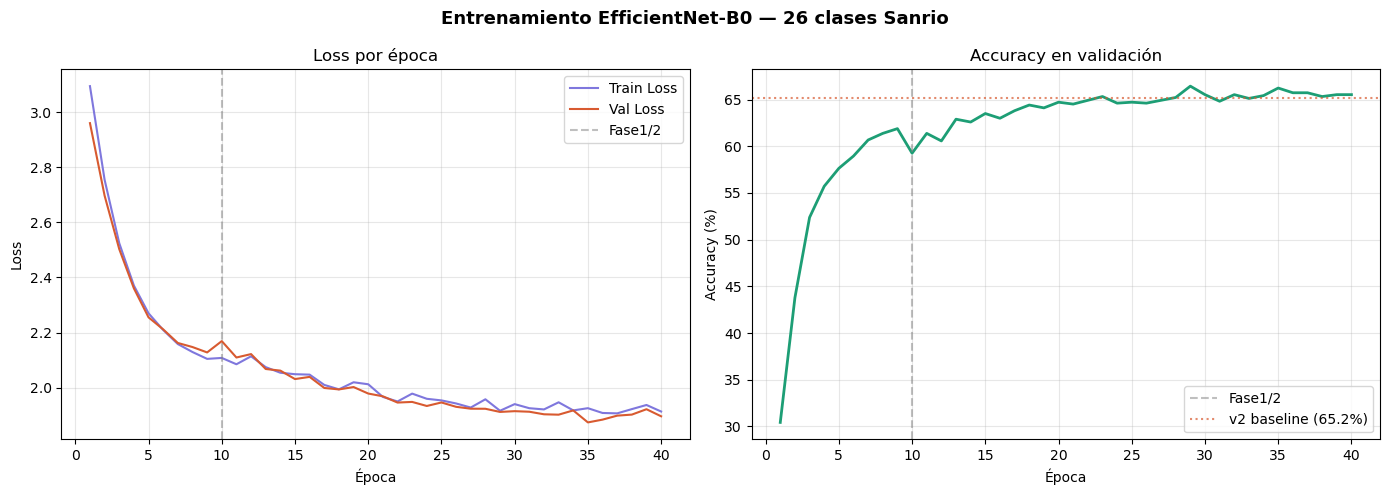

Gráfica guardada.


In [7]:
# ============================================================
# Celda 7 — Guardar modelo + graficar historial
# ============================================================

# Guardar pesos
ruta_pth = os.path.join(RUTA_MODELOS, 'tl_sanrio_v3_final.pth')
torch.save(model.state_dict(), ruta_pth)
print(f'✅ Modelo guardado: {ruta_pth}')

# Guardar metadata del entrenamiento
metadata = {
    'version': VERSION,
    'arquitectura': 'EfficientNet-B0',
    'num_clases': NUM_CLASES,
    'clases': clases,
    'mejor_accuracy': max(historial['test_acc']),
    'accuracy_final': historial['test_acc'][-1],
    'config': CONFIG,
    'fecha': datetime.now().strftime('%Y-%m-%d %H:%M'),
}
ruta_meta = os.path.join(RUTA_MODELOS, 'metadata_v3.json')
with open(ruta_meta, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f'✅ Metadata guardada: {ruta_meta}')

# ── Gráfica de entrenamiento ────────────────────────────────
epocas = range(1, len(historial['train_loss']) + 1)
sep    = CONFIG['EPOCHS_FASE1']  # Línea divisoria Fase1/Fase2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Entrenamiento EfficientNet-B0 — {NUM_CLASES} clases Sanrio',
             fontsize=13, fontweight='bold')

ax1.plot(epocas, historial['train_loss'], label='Train Loss', color='#7F77DD')
ax1.plot(epocas, historial['test_loss'],  label='Val Loss',   color='#D85A30')
ax1.axvline(x=sep, color='gray', linestyle='--', alpha=0.5, label='Fase1/2')
ax1.set_title('Loss por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epocas, historial['test_acc'], color='#1D9E75', linewidth=2)
ax2.axvline(x=sep, color='gray', linestyle='--', alpha=0.5, label='Fase1/2')
ax2.axhline(y=65.2, color='#D85A30', linestyle=':', alpha=0.7, label='v2 baseline (65.2%)')
ax2.set_title('Accuracy en validación')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_MODELOS, 'historial_v3.png'), dpi=120)
plt.show()
print('Gráfica guardada.')

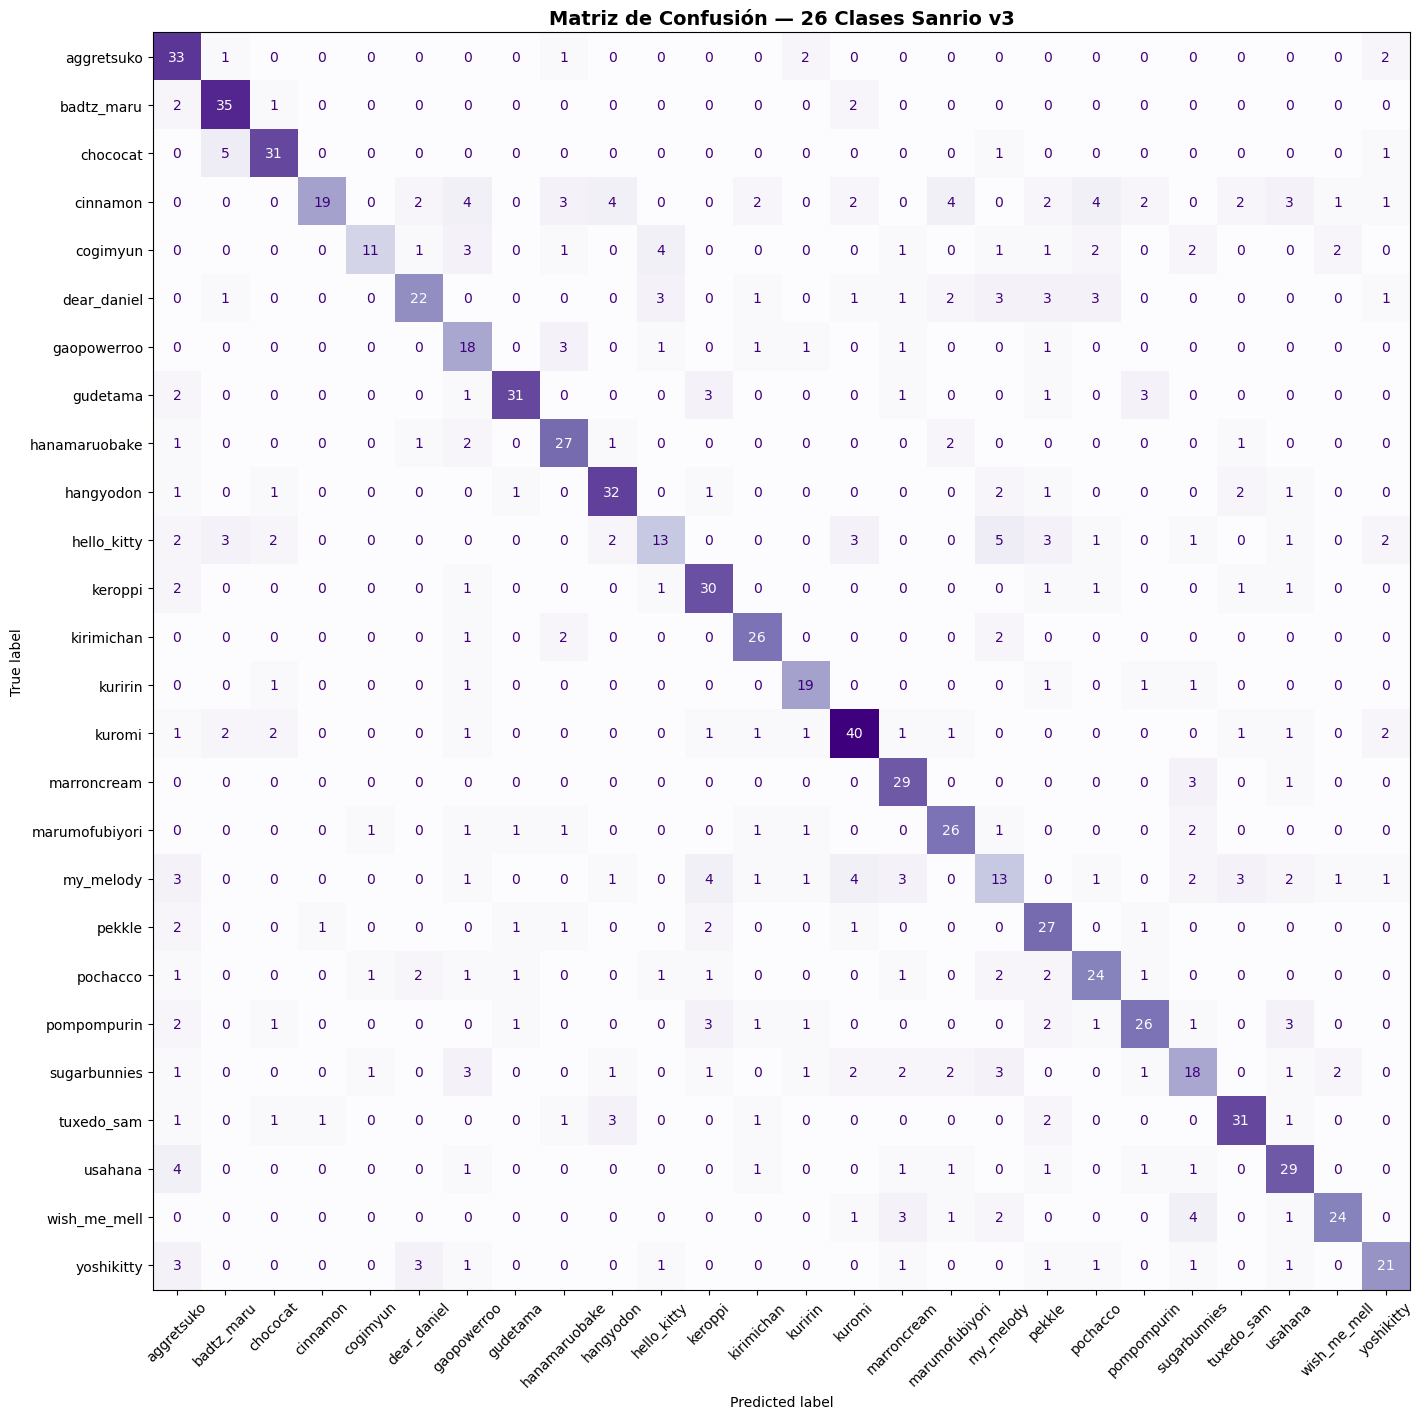


  ACCURACY POR CLASE — v3
  Clase                       Aciertos     Acc
  ------------------------------------------
  aggretsuko                 33/39   =  84.6% ################
  badtz_maru                 35/40   =  87.5% #################
  chococat                   31/38   =  81.6% ################
  cinnamon                   19/55   =  34.5% ######
  cogimyun                   11/29   =  37.9% #######
  dear_daniel                22/41   =  53.7% ##########
  gaopowerroo                18/26   =  69.2% #############
  gudetama                   31/42   =  73.8% ##############
  hanamaruobake              27/35   =  77.1% ###############
  hangyodon                  32/42   =  76.2% ###############
  hello_kitty                13/38   =  34.2% ######
  keroppi                    30/38   =  78.9% ###############
  kirimichan                 26/31   =  83.9% ################
  kuririn                    19/24   =  79.2% ###############
  kuromi                     40/55   =  72

In [8]:
# ============================================================
# Celda 8 — Evaluación detallada: accuracy por clase
# ============================================================

plt.close('all')
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()

model.eval()
todas_reales    = []
todas_predichas = []

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes  = imagenes.to(device)
        outputs   = model(imagenes)
        _, predichas = torch.max(outputs, 1)
        todas_reales.extend(etiquetas.cpu().numpy())
        todas_predichas.extend(predichas.cpu().numpy())

cm = confusion_matrix(todas_reales, todas_predichas)

# Matriz de confusión
fig, ax = plt.subplots(figsize=(max(10, NUM_CLASES * 0.65),
                                max(8,  NUM_CLASES * 0.55)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(ax=ax, cmap='Purples', colorbar=False,
          values_format='d', xticks_rotation=45)
ax.set_title(f'Matriz de Confusión — {NUM_CLASES} Clases Sanrio v3',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RUTA_MODELOS, 'confusion_matrix_v3.png'), dpi=120)
plt.show()

# Accuracy por clase
print(f'\n{"="*55}')
print(f'  ACCURACY POR CLASE — v3')
print(f'{"="*55}')
print(f'  {"Clase":25s} {"Aciertos":>10s} {"Acc":>7s}')
print(f'  {"-"*42}')

suma_acc   = 0
total_ok   = 0
total_imgs_test = 0

for i, clase in enumerate(clases):
    mask    = [r == i for r in todas_reales]
    reales  = [p for p, m in zip(todas_predichas, mask) if m]
    ok      = sum(1 for p in reales if p == i)
    total   = len(reales)
    acc_c   = 100.0 * ok / total if total > 0 else 0
    barra   = '#' * max(1, int(acc_c / 5))
    suma_acc += acc_c
    total_ok += ok
    total_imgs_test += total
    print(f'  {clase:25s} {ok:3d}/{total:<3d}  = {acc_c:5.1f}% {barra}')

print(f'  {"-"*42}')
print(f'  {"ACCURACY GLOBAL":25s} {total_ok}/{total_imgs_test} = '
      f'{100.0*total_ok/total_imgs_test:.1f}%')
print(f'  {"ACCURACY PROMEDIO":25s} {suma_acc/NUM_CLASES:.1f}%')
print(f'  {"BASELINE v2":25s} 65.2%')
mejora = (100.0*total_ok/total_imgs_test) - 65.2
print(f'  {"MEJORA":25s} {mejora:+.1f}%')

# Pares más confundidos
print(f'\n{"="*55}')
print(f'  PARES MÁS CONFUNDIDOS')
print(f'{"="*55}')
confusiones = []
for i in range(NUM_CLASES):
    for j in range(NUM_CLASES):
        if i != j and cm[i][j] > 0:
            confusiones.append((cm[i][j], clases[i], clases[j]))
confusiones.sort(reverse=True)
for n, real, pred in confusiones[:8]:
    print(f'  {real:20s} -> {pred:20s} : {n} veces')

In [9]:
# ============================================================
# Celda 9 — Export ONNX INT8
#
# Si falla por falta de 'onnx':
#   conda activate diplomado-redes
#   pip install onnx onnxruntime
# ============================================================

try:
    import onnx
    from torch.ao.quantization import quantize_dynamic

    ruta_onnx_fp32 = os.path.join(RUTA_MODELS, 'tl_sanrio_v3.onnx')
    ruta_onnx_int8 = os.path.join(RUTA_MODELS, 'tl_sanrio_v3_int8.onnx')

    # Export FP32
    model.eval()
    dummy = torch.randn(1, 3, 224, 224).to(device)
    torch.onnx.export(
        model, dummy, ruta_onnx_fp32,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}},
        opset_version=17,
        export_params=True,
    )
    size_fp32 = os.path.getsize(ruta_onnx_fp32) / 1e6
    print(f'✅ ONNX FP32: {ruta_onnx_fp32} ({size_fp32:.1f} MB)')

    # Cuantización INT8 (reduce ~4x el tamaño)
    model_cpu = model.cpu()
    model_int8 = quantize_dynamic(model_cpu, {nn.Linear}, dtype=torch.qint8)
    dummy_cpu = torch.randn(1, 3, 224, 224)
    torch.onnx.export(
        model_int8, dummy_cpu, ruta_onnx_int8,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}},
        opset_version=17,
    )
    size_int8 = os.path.getsize(ruta_onnx_int8) / 1e6
    print(f'✅ ONNX INT8: {ruta_onnx_int8} ({size_int8:.1f} MB)')
    print(f'   Reducción: {size_fp32/size_int8:.1f}x más ligero')

    # Copiar clases al directorio models/
    import shutil
    shutil.copy(
        os.path.join(RUTA_MODELOS, 'clases_sanrio_v3.json'),
        os.path.join(RUTA_MODELS,  'clases_sanrio_v3.json')
    )
    print(f'✅ clases_sanrio_v3.json copiado a models/')

except ModuleNotFoundError:
    print('⚠️  onnx no instalado. Para exportar:')
    print('   pip install onnx onnxruntime')
    print('   Luego re-ejecuta esta celda.')
    print(f'\n   El .pth está guardado en: {ruta_pth}')
except Exception as e:
    print(f'⚠️  Error al exportar ONNX: {e}')
    print(f'   El .pth está disponible para exportar manualmente.')

✅ ONNX FP32: d:\Diplomado-RNA\Modulo-4\Proyectos\Final\models\tl_sanrio_v3.onnx (16.2 MB)
⚠️  Error al exportar ONNX: Exporting the operator 'quantized::linear_dynamic' to ONNX opset version 17 is not supported. Please feel free to request support or submit a pull request on PyTorch GitHub: https://github.com/pytorch/pytorch/issues.
   El .pth está disponible para exportar manualmente.


In [10]:
# ============================================================
# Celda 10 — Footer / resumen ejecutivo
# ============================================================

import psutil, platform

fin      = time.time()
segundos = fin - INICIO
mm, ss   = divmod(int(segundos), 60)
hh, mm   = divmod(mm, 60)

print()
print('=' * 60)
print(f'  Hecho con cariño por {AUTORA}')
print(f'  Diplomado RNA — Módulo 4: Deep Learning')
print(f'  UAEM — Julio 2026')
print()
print(f'  Especificaciones:')
try:
    print(f'  CPU: {platform.processor()}')
except: pass
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1)
    print(f'  GPU: {gpu_name} ({gpu_mem} GB)')
try:
    print(f'  RAM: {round(psutil.virtual_memory().total / 1e9, 1)} GB')
except: pass
print(f'  PyTorch {torch.__version__}')
print()
print(f'  Versión:        {VERSION}')
print(f'  Tiempo:         {hh:d}h {mm:02d}m {ss:02d}s')
print(f'  Accuracy final: {historial["test_acc"][-1]:.2f}%')
print(f'  Mejor accuracy: {max(historial["test_acc"]):.2f}%')
print(f'  Baseline v2:    65.2%')
print(f'  Mejora:         {max(historial["test_acc"]) - 65.2:+.2f}%')
print(f'  Clases:         {NUM_CLASES}')
print(f'  Train imgs:     {total_imgs}')
print(f'  Test imgs:      {len(test_dataset)}')
print(f'  Fecha:          {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print('=' * 60)
print()
print('  ✅ PARA PRODUCCIÓN:')
print('  1. Copia models/tl_sanrio_v3_int8.onnx → app/')
print('  2. Copia models/clases_sanrio_v3.json  → app/')
print('  3. uvicorn app.main:app --host 0.0.0.0 --port 8000')
print('  4. Deploy: docker build -t sanrio-classifier .')


  Hecho con cariño por Diana Blanco - MorritaConP1to
  Diplomado RNA — Módulo 4: Deep Learning
  UAEM — Julio 2026

  Especificaciones:
  CPU: AMD64 Family 23 Model 113 Stepping 0, AuthenticAMD
  GPU: NVIDIA GeForce RTX 4060 (8.6 GB)
  RAM: 34.3 GB
  PyTorch 2.5.1+cu121

  Versión:        v3-EfficientNet
  Tiempo:         0h 40m 50s
  Accuracy final: 65.52%
  Mejor accuracy: 66.43%
  Baseline v2:    65.2%
  Mejora:         +1.23%
  Clases:         26
  Train imgs:     3957
  Test imgs:      989
  Fecha:          2026-06-30 19:09

  ✅ PARA PRODUCCIÓN:
  1. Copia models/tl_sanrio_v3_int8.onnx → app/
  2. Copia models/clases_sanrio_v3.json  → app/
  3. uvicorn app.main:app --host 0.0.0.0 --port 8000
  4. Deploy: docker build -t sanrio-classifier .
